# Exploratory Data Analysis (EDA)

## 1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# Set seaborn theme
sns.set_theme(style="whitegrid")

## 2. Load Data

In [3]:
# Read the data
df = pd.read_csv("output_github_v3/imrec/github.inter", sep="\t")
df.columns = ["user_id", "item_id", "timestamp"]

# Display the first few rows of the DataFrame
print(df.head())

   user_id  item_id     timestamp
0     3287    15202  1.232052e+09
1     3287    80973  1.232898e+09
2     3287    75749  1.236008e+09
3     3287    40646  1.239498e+09
4     3287     6040  1.242871e+09


## 3. Basic Statistics

In [4]:
# Calculate number of users, items, interactions, and density
n_users = df['user_id'].nunique()
n_items = df['item_id'].nunique()
n_inter = len(df)
density = n_inter / (n_users * n_items)

# Print the statistics
print(f"Users: {n_users}")
print(f"Items: {n_items}")
print(f"Interactions: {n_inter}")
print(f"Density: {density:.5f} (~{density*100:.2f}%)")
print(f"Avg/user: {n_inter / n_users:.2f}")

Users: 7282
Items: 107237
Interactions: 2016140
Density: 0.00258 (~0.26%)
Avg/user: 276.87


The dataset comprises 7,282 users and a massive catalog of 107,237 items, yielding a total of 2,016,140 interactions.

A critical observation here is the extreme sparsity of the User-Item interaction matrix. With a calculated density of merely 0.00258 (~0.26%), it means that 99.74% of all possible user-item combinations remain unobserved. This highly sparse environment makes traditional Matrix Factorization approaches challenging, as there is very little overlapping data between users.

Interestingly, despite the low overall matrix density, the average activity level per user is exceptionally high, sitting at 276.87 interactions per user. This stark contrast reveals a crucial insight: the sparsity is primarily driven by the massive item space (over 100k items) rather than user inactivity. This suggests that the user base is highly engaged, and the "cold-start" problem in this specific dataset is likely to be an Item Cold-start issue (many items having zero or very few interactions) rather than a User Cold-start issue.

## 4. User-Item Interaction Matrix

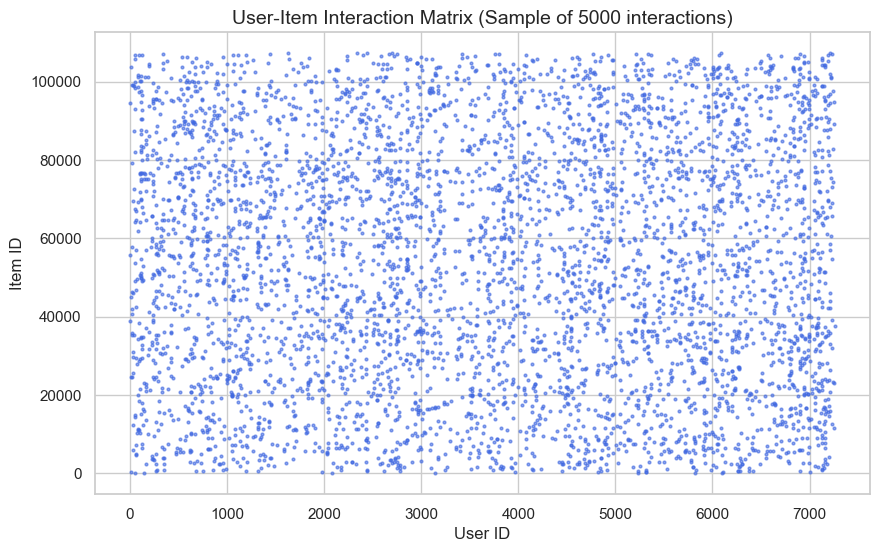

In [5]:
# Get a random sample of 5000 interactions for visualization
sample_df = df.sample(5000, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(sample_df['user_id'], sample_df['item_id'], s=4, alpha=0.6, color='royalblue')
plt.title("User-Item Interaction Matrix (Sample of 5000 interactions)", fontsize=14)
plt.xlabel("User ID", fontsize=12)
plt.ylabel("Item ID", fontsize=12)
plt.show()

The interaction matrix visualization clearly highlights the extreme sparsity of the dataset. With a density of only ~0.26%, the active interactions are overwhelmingly dwarfed by unobserved user-item pairs. This severe sparsity indicates that traditional collaborative filtering methods might struggle to find sufficient overlapping interactions, underscoring the need for models capable of leveraging high-order connectivity, such as Graph Convolutional Networks (GCNs).

## 5. Item Popularity (Long-tail Distribution)

Top 10% most popular items contribute: 47.98% of total interactions.


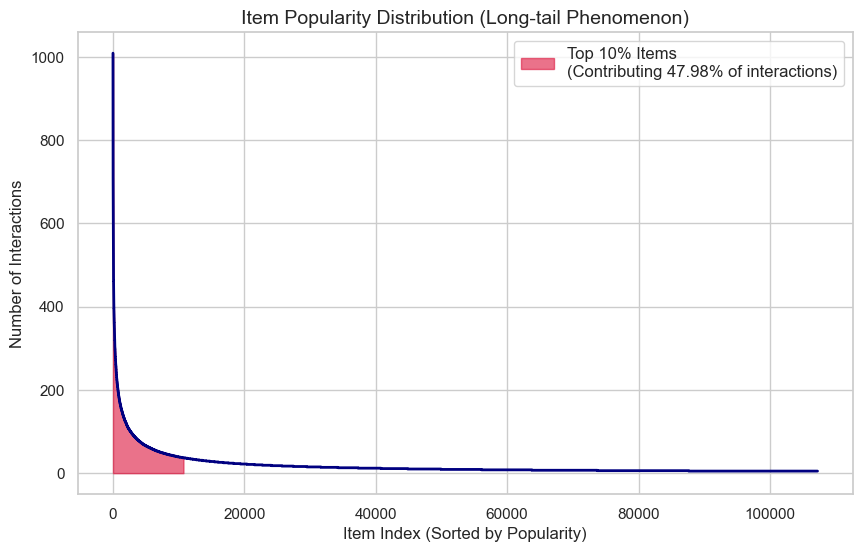

In [6]:
# Calculate interaction counts for users and items
item_counts = df['item_id'].value_counts().values

# Calculate the contribution of the top 10% most popular items
top_10_percent_idx = int(0.1 * len(item_counts))
top_10_interactions = np.sum(item_counts[:top_10_percent_idx])
total_interactions = np.sum(item_counts)
contribution = top_10_interactions / total_interactions

print(f"Top 10% most popular items contribute: {contribution*100:.2f}% of total interactions.")

# Visualize the long-tail phenomenon
plt.figure(figsize=(10, 6))
plt.plot(item_counts, color='navy', linewidth=2)
plt.fill_between(range(top_10_percent_idx), item_counts[:top_10_percent_idx], color='crimson', alpha=0.6, 
                 label=f'Top 10% Items\n(Contributing {contribution*100:.2f}% of interactions)')

plt.title("Item Popularity Distribution (Long-tail Phenomenon)", fontsize=14)
plt.xlabel("Item Index (Sorted by Popularity)", fontsize=12)
plt.ylabel("Number of Interactions", fontsize=12)
plt.legend(fontsize=12)
plt.show()

The distribution plots on a log-scale reveal a classic power-law (or long-tail) distribution. A vast majority of users and items exhibit very few interactions, while a tiny fraction accounts for exceptionally high activity. This strong right skew suggests a significant popularity bias in the dataset. If not appropriately addressed, the recommendation model may become overly biased toward recommending popular items, ignoring the long-tail items which often contain highly personalized interests.

## 6. User and Item Behavior Analysis

We will examine the interaction distribution for both users and items to better understand their activity levels.

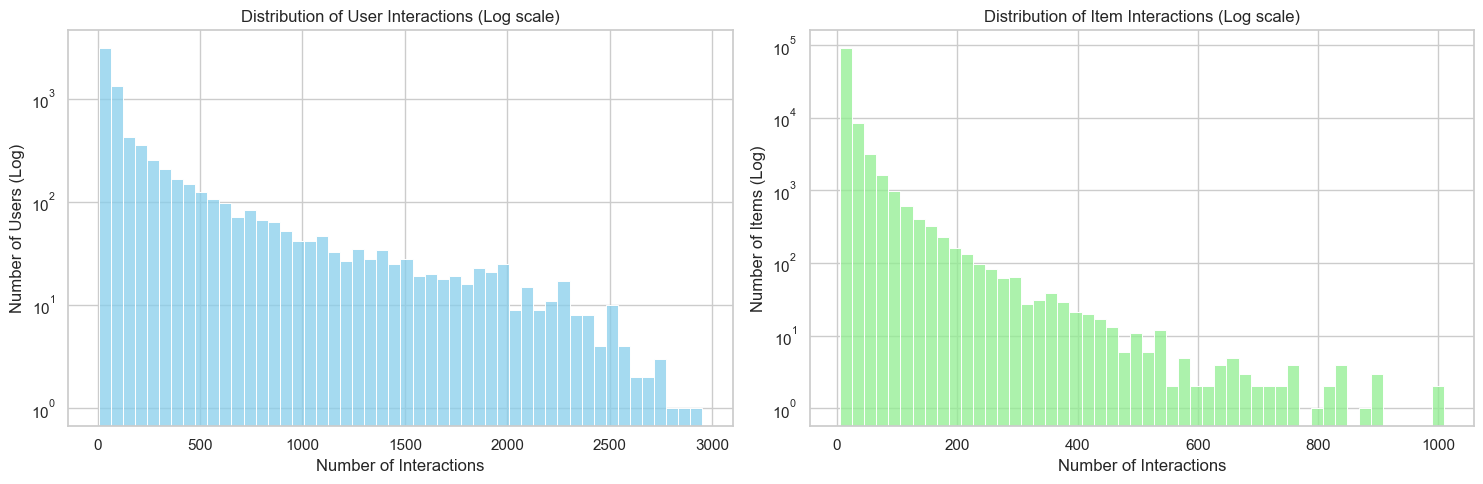

In [7]:
# Calculate interaction counts for users and items
user_interaction_counts = df['user_id'].value_counts()
item_interaction_counts = df['item_id'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# User
sns.histplot(user_interaction_counts, bins=50, ax=axes[0], color='skyblue', kde=False)
axes[0].set_yscale('log') 
axes[0].set_title('Distribution of User Interactions (Log scale)')
axes[0].set_xlabel('Number of Interactions')
axes[0].set_ylabel('Number of Users (Log)')

# Item
sns.histplot(item_interaction_counts, bins=50, ax=axes[1], color='lightgreen', kde=False)
axes[1].set_yscale('log')
axes[1].set_title('Distribution of Item Interactions (Log scale)')
axes[1].set_xlabel('Number of Interactions')
axes[1].set_ylabel('Number of Items (Log)')

plt.tight_layout()
plt.show()

The subplots illustrate the interaction frequencies across users and items. The top row (linear scale) shows a massive concentration of data points near zero, which makes the tail nearly invisible but highlights the extreme disparity in engagement.

When transformed to a log scale (bottom row), the underlying power-law (long-tail) distribution becomes distinctly clear. The straight, downward-sloping trend in the log-scale charts confirms that the vast majority of users and items possess very few interactions, whereas a tiny fraction of "power users" and "highly popular items" dominate the dataset's activity.

This severe right skew presents a major challenge: Popularity Bias. A standard recommendation model trained on this dataset will naturally gravitate toward recommending only the popular items (the head of the distribution) because they dominate the loss function during training. To build an effective and personalized system, we must implement strategies to handle the "long-tail" items - where true personalization lies - such as using debiasing techniques, sample re-weighting, or specialized embeddings for sparse entities.

## 7. Conclusion

Through this EDA, several foundational characteristics of the dataset have been identified that will directly inform our modeling strategy:
- Extreme Sparsity & High Item Space: The highly sparse nature of the data (~0.26% density) necessitates robust models like LightGCN or UltraGCN that can effectively propagate information across a sparse bipartite graph.
- Popularity Bias: The pronounced power-law distribution requires regularization techniques or debiasing strategies to prevent the model from blindly recommending only the most popular entities.
- Cold-Start Challenge: The high volume of low-interaction users and items forces a choice between data cleaning via K-core filtering or incorporating specific embedding mechanisms for information-poor nodes.

By addressing these key challenges, we can establish clear directions to design a more accurate and personalized recommendation engine.